# Burned Area Student Size Probe

This notebook focuses on the remaining float-expert mismatch after fixing the
missing Phi2FM min-max preprocessing.

It answers two questions:

1. How much did the old Hydra float path differ from the corrected Phi2FM-aligned
   path on real student checkpoints?
2. How much drift remains because Hydra uses `256x256` while the local Phi2FM
   student configs for these tasks were trained with `224x224`?

The notebook computes both effects on representative patches for:

- `anomaly_detection`
- `burned_area`
- `fire`
- `worldfloods`

Then it renders a burned-area-focused visual inspection over several patches.


In [1]:
from __future__ import annotations

import contextlib
import io
import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from hydranet import load_student
from hydranet.moe_training import (
    _normalize_routerset_array_impl,
    _reduce_expert_output_to_routing_score,
    crop_or_pad_routerset_tensor,
)

DATASET_ROOT = PROJECT_ROOT / 'outputs' / 'routerset' / 'fix30March_floatminmax_selected_anomalyfix'
MANIFEST_PATH = DATASET_ROOT / 'manifest_256.jsonl'
REPORT_PATH = DATASET_ROOT / 'float_student_size_probe_summary.json'

EXPERTS = ['anomaly_detection', 'burned_area', 'fire', 'worldfloods']
SAMPLES_PER_SPLIT = 2
TARGET_224 = 224
TARGET_256 = 256
TARGET_CHANNELS = 8
DEVICE = 'cpu'

torch.set_grad_enabled(False)
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
set_matplotlib_formats('png')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.max_open_warning'] = 0

print('project_root:', PROJECT_ROOT)
print('dataset_root:', DATASET_ROOT)
print('manifest_exists:', MANIFEST_PATH.exists())


project_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2
dataset_root: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix
manifest_exists: True


In [2]:
def resolve_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def load_manifest_rows(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


def load_source_patch(row: dict) -> np.ndarray:
    source_path = resolve_path(row['materialized_from'])
    source = np.load(source_path, mmap_mode='r')
    current = np.array(source, copy=True)
    if row['source_dataset'] == 'anomaly_detection':
        patch_y = int(row['patch_y'])
        patch_x = int(row['patch_x'])
        patch_h = int(row.get('patch_h', row.get('patch_height', TARGET_256)))
        patch_w = int(row.get('patch_w', row.get('patch_width', TARGET_256)))
        current = current[:, patch_y:patch_y + patch_h, patch_x:patch_x + patch_w]
    return current


def old_float_channel_adapter(array: np.ndarray, target_channels: int = TARGET_CHANNELS) -> np.ndarray:
    current = np.array(array, dtype=np.float32, copy=True)
    current = np.nan_to_num(current, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    if current.ndim != 3:
        raise ValueError(f'Expected CHW array, got {current.shape}')
    channels, height, width = current.shape
    if channels > target_channels:
        current = current[:target_channels]
    elif channels < target_channels:
        pad = np.zeros((target_channels - channels, height, width), dtype=np.float32)
        current = np.concatenate([current, pad], axis=0)
    return current.astype(np.float32, copy=False)


def build_fixed_patch(row: dict, *, target_size: int) -> tuple[np.ndarray, str]:
    source = load_source_patch(row)
    normalized, _, normalization_mode, _ = _normalize_routerset_array_impl(
        source,
        source_dataset=row['source_dataset'],
        target_channels=TARGET_CHANNELS,
    )
    tensor = crop_or_pad_routerset_tensor(torch.from_numpy(np.array(normalized, copy=True)), target_size=target_size)
    return tensor.numpy().astype(np.float32, copy=False), normalization_mode


def build_old_patch(row: dict, *, target_size: int) -> np.ndarray:
    source = load_source_patch(row)
    current = old_float_channel_adapter(source)
    tensor = crop_or_pad_routerset_tensor(torch.from_numpy(np.array(current, copy=True)), target_size=target_size)
    return tensor.numpy().astype(np.float32, copy=False)


def load_materialized_patch(row: dict) -> np.ndarray:
    return np.load(resolve_path(row['materialized_image_path'])).astype(np.float32, copy=False)


def center_crop_array(array: np.ndarray, target_size: int) -> np.ndarray:
    if array.ndim == 3:
        _, height, width = array.shape
        top = max((height - target_size) // 2, 0)
        left = max((width - target_size) // 2, 0)
        return array[:, top:top + target_size, left:left + target_size]
    if array.ndim == 2:
        height, width = array.shape
        top = max((height - target_size) // 2, 0)
        left = max((width - target_size) // 2, 0)
        return array[top:top + target_size, left:left + target_size]
    raise ValueError(f'Expected 2D or 3D array, got {array.shape}')


def normalize_display(chw: np.ndarray, channels: tuple[int, int, int]) -> np.ndarray:
    rgb = np.stack([chw[index] for index in channels], axis=-1).astype(np.float32)
    lo = np.percentile(rgb, 2.0)
    hi = np.percentile(rgb, 98.0)
    if hi <= lo:
        return np.clip(rgb, 0.0, 1.0)
    rgb = (rgb - lo) / (hi - lo)
    return np.clip(rgb, 0.0, 1.0)


def infer_patch(model: torch.nn.Module, chw: np.ndarray) -> dict:
    x = torch.from_numpy(np.array(chw, copy=True)).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(dim=1)[0].detach().cpu().numpy()
    conf = probs.max(dim=1).values[0].detach().cpu().numpy()
    score = _reduce_expert_output_to_routing_score(logits.detach().cpu())
    return {
        'logits': logits[0].detach().cpu().numpy(),
        'pred': pred,
        'conf': conf,
        'score': float(score),
    }


def compare_same_shape(reference: dict, candidate: dict) -> dict:
    logit_mae = float(np.mean(np.abs(reference['logits'] - candidate['logits'])))
    disagreement = float(np.mean(reference['pred'] != candidate['pred']))
    conf_delta_mean = float(np.mean(candidate['conf'] - reference['conf']))
    score_delta = float(candidate['score'] - reference['score'])
    return {
        'logit_mae': logit_mae,
        'disagreement_fraction': disagreement,
        'confidence_delta_mean': conf_delta_mean,
        'score_delta': score_delta,
    }


def compare_size(reference_256: dict, candidate_224: dict) -> dict:
    ref_logits = center_crop_array(reference_256['logits'], TARGET_224)
    ref_pred = center_crop_array(reference_256['pred'], TARGET_224)
    ref_conf = center_crop_array(reference_256['conf'], TARGET_224)
    logit_mae = float(np.mean(np.abs(ref_logits - candidate_224['logits'])))
    disagreement = float(np.mean(ref_pred != candidate_224['pred']))
    conf_delta_mean = float(np.mean(candidate_224['conf'] - ref_conf))
    score_delta = float(candidate_224['score'] - reference_256['score'])
    return {
        'logit_mae': logit_mae,
        'disagreement_fraction': disagreement,
        'confidence_delta_mean': conf_delta_mean,
        'score_delta': score_delta,
    }


def mean_metric(rows: list[dict], key: str) -> float:
    return float(statistics.mean(item[key] for item in rows))


def markdown_table(rows: list[dict], columns: list[tuple[str, str]]) -> str:
    header = '| ' + ' | '.join(label for _, label in columns) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    body = []
    for row in rows:
        body.append('| ' + ' | '.join(str(row[key]) for key, _ in columns) + ' |')
    return '\n'.join([header, divider, *body])


In [3]:
rows = load_manifest_rows(MANIFEST_PATH)

rows_by_expert_split: dict[tuple[str, str], list[dict]] = {}
for row in rows:
    expert = row['source_dataset']
    split = row.get('moe_split', row['source_split'])
    if expert not in EXPERTS:
        continue
    rows_by_expert_split.setdefault((expert, split), []).append(row)

probe_rows_by_expert: dict[str, list[dict]] = {}
for expert in EXPERTS:
    selected = []
    for split in ('train', 'validation'):
        group = sorted(
            rows_by_expert_split[(expert, split)],
            key=lambda row: (str(row['source_sample_id']), str(row['materialized_image_path'])),
        )
        selected.extend(group[:SAMPLES_PER_SPLIT])
    probe_rows_by_expert[expert] = selected

models = {}
for expert in EXPERTS:
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        model = load_student(task=expert, training='finetuning', n_shots=5000, auto_load_weights=True)
    model.eval()
    model.to(DEVICE)
    models[expert] = model

selection_summary = {
    expert: [
        {
            'split': row.get('moe_split', row['source_split']),
            'sample_id': row['source_sample_id'],
            'materialized_image_path': row['materialized_image_path'],
        }
        for row in selected_rows
    ]
    for expert, selected_rows in probe_rows_by_expert.items()
}
print(json.dumps(selection_summary, indent=2))


{
  "anomaly_detection": [
    {
      "split": "train",
      "sample_id": "0000000",
      "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/train/0000000_0_0_256_256.npy"
    },
    {
      "split": "train",
      "sample_id": "0000000",
      "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/train/0000000_0_1024_256_256.npy"
    },
    {
      "split": "validation",
      "sample_id": "0000001",
      "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/validation/0000001_0_0_256_256.npy"
    },
    {
      "split": "validation",
      "sample_id": "0000001",
      "materialized_image_path": "outputs/routerset/fix30March_floatminmax_selected_anomalyfix/images/anomaly_detection/validation/0000001_0_1024_256_256.npy"
    }
  ],
  "burned_area": [
    {
      "split": "train",
      "sample_id": "00

In [4]:
probe_report = {
    'dataset_root': str(DATASET_ROOT),
    'target_sizes': {'student_config': TARGET_224, 'hydra': TARGET_256},
    'per_expert': {},
}

table_rows = []
for expert in EXPERTS:
    model = models[expert]
    sample_metrics = []
    for row in probe_rows_by_expert[expert]:
        fixed_256, normalization_mode = build_fixed_patch(row, target_size=TARGET_256)
        fixed_224, _ = build_fixed_patch(row, target_size=TARGET_224)
        old_256 = build_old_patch(row, target_size=TARGET_256)
        materialized = load_materialized_patch(row)

        fixed_256_out = infer_patch(model, fixed_256)
        fixed_224_out = infer_patch(model, fixed_224)
        old_256_out = infer_patch(model, old_256)

        old_vs_fixed = compare_same_shape(fixed_256_out, old_256_out)
        size_vs_fixed = compare_size(fixed_256_out, fixed_224_out)
        materialized_mae = float(np.mean(np.abs(fixed_256 - materialized)))

        sample_metrics.append(
            {
                'sample_id': row['source_sample_id'],
                'split': row.get('moe_split', row['source_split']),
                'normalization_mode': normalization_mode,
                'materialized_match_mae': materialized_mae,
                'old_vs_fixed': old_vs_fixed,
                'size_224_vs_256': size_vs_fixed,
            }
        )

    expert_summary = {
        'normalization_modes': sorted({sample['normalization_mode'] for sample in sample_metrics}),
        'mean_materialized_match_mae': mean_metric(sample_metrics, 'materialized_match_mae'),
        'old_vs_fixed_mean_logit_mae': mean_metric([sample['old_vs_fixed'] for sample in sample_metrics], 'logit_mae'),
        'old_vs_fixed_mean_disagreement': mean_metric([sample['old_vs_fixed'] for sample in sample_metrics], 'disagreement_fraction'),
        'old_vs_fixed_mean_score_delta': mean_metric([sample['old_vs_fixed'] for sample in sample_metrics], 'score_delta'),
        'size_224_vs_256_mean_logit_mae': mean_metric([sample['size_224_vs_256'] for sample in sample_metrics], 'logit_mae'),
        'size_224_vs_256_mean_disagreement': mean_metric([sample['size_224_vs_256'] for sample in sample_metrics], 'disagreement_fraction'),
        'size_224_vs_256_mean_score_delta': mean_metric([sample['size_224_vs_256'] for sample in sample_metrics], 'score_delta'),
        'samples': sample_metrics,
    }
    probe_report['per_expert'][expert] = expert_summary
    table_rows.append(
        {
            'expert': expert,
            'old_logit_mae': f"{expert_summary['old_vs_fixed_mean_logit_mae']:.4f}",
            'old_disagree': f"{expert_summary['old_vs_fixed_mean_disagreement']:.4f}",
            'size_logit_mae': f"{expert_summary['size_224_vs_256_mean_logit_mae']:.4f}",
            'size_disagree': f"{expert_summary['size_224_vs_256_mean_disagreement']:.4f}",
            'materialized_mae': f"{expert_summary['mean_materialized_match_mae']:.6f}",
        }
    )

REPORT_PATH.write_text(json.dumps(probe_report, indent=2), encoding='utf-8')

display(Markdown('## Cross-Expert Summary'))
display(
    Markdown(
        markdown_table(
            table_rows,
            [
                ('expert', 'expert'),
                ('old_logit_mae', 'old vs fixed logit MAE'),
                ('old_disagree', 'old vs fixed disagree'),
                ('size_logit_mae', '224 vs 256 logit MAE'),
                ('size_disagree', '224 vs 256 disagree'),
                ('materialized_mae', 'fixed256 vs materialized MAE'),
            ],
        )
    )
)
print('summary_report:', REPORT_PATH)
print(json.dumps(probe_report, indent=2))


## Cross-Expert Summary

| expert | old vs fixed logit MAE | old vs fixed disagree | 224 vs 256 logit MAE | 224 vs 256 disagree | fixed256 vs materialized MAE |
| --- | --- | --- | --- | --- | --- |
| anomaly_detection | 0.1552 | 0.0000 | 0.0000 | 0.0000 | 0.000000 |
| burned_area | 0.0040 | 0.0004 | 0.0080 | 0.0009 | 0.000000 |
| fire | 0.0238 | 0.0042 | 0.0000 | 0.0000 | 0.000000 |
| worldfloods | 0.0086 | 0.0000 | 0.0000 | 0.0000 | 0.000000 |

summary_report: /shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix/float_student_size_probe_summary.json
{
  "dataset_root": "/shared/home/rdelprete/PythonProjects/hydranet-phisat2/outputs/routerset/fix30March_floatminmax_selected_anomalyfix",
  "target_sizes": {
    "student_config": 224,
    "hydra": 256
  },
  "per_expert": {
    "anomaly_detection": {
      "normalization_modes": [
        "phi2fm_student_float_minmax"
      ],
      "mean_materialized_match_mae": 0.0,
      "old_vs_fixed_mean_logit_mae": 0.1552287731319666,
      "old_vs_fixed_mean_disagreement": 0.0,
      "old_vs_fixed_mean_score_delta": -0.0008023381233215332,
      "size_224_vs_256_mean_logit_mae": 1.33560806858668e-07,
      "size_224_vs_256_mean_disagreement": 0.0,
      "size_224_vs_256_mean_score_delta": -8.493661880493164e-07,
      "samples": [
        {
          "sample_id": "0000000",
          "split": "train",
          "normalization_

## Burned Area Visual Focus

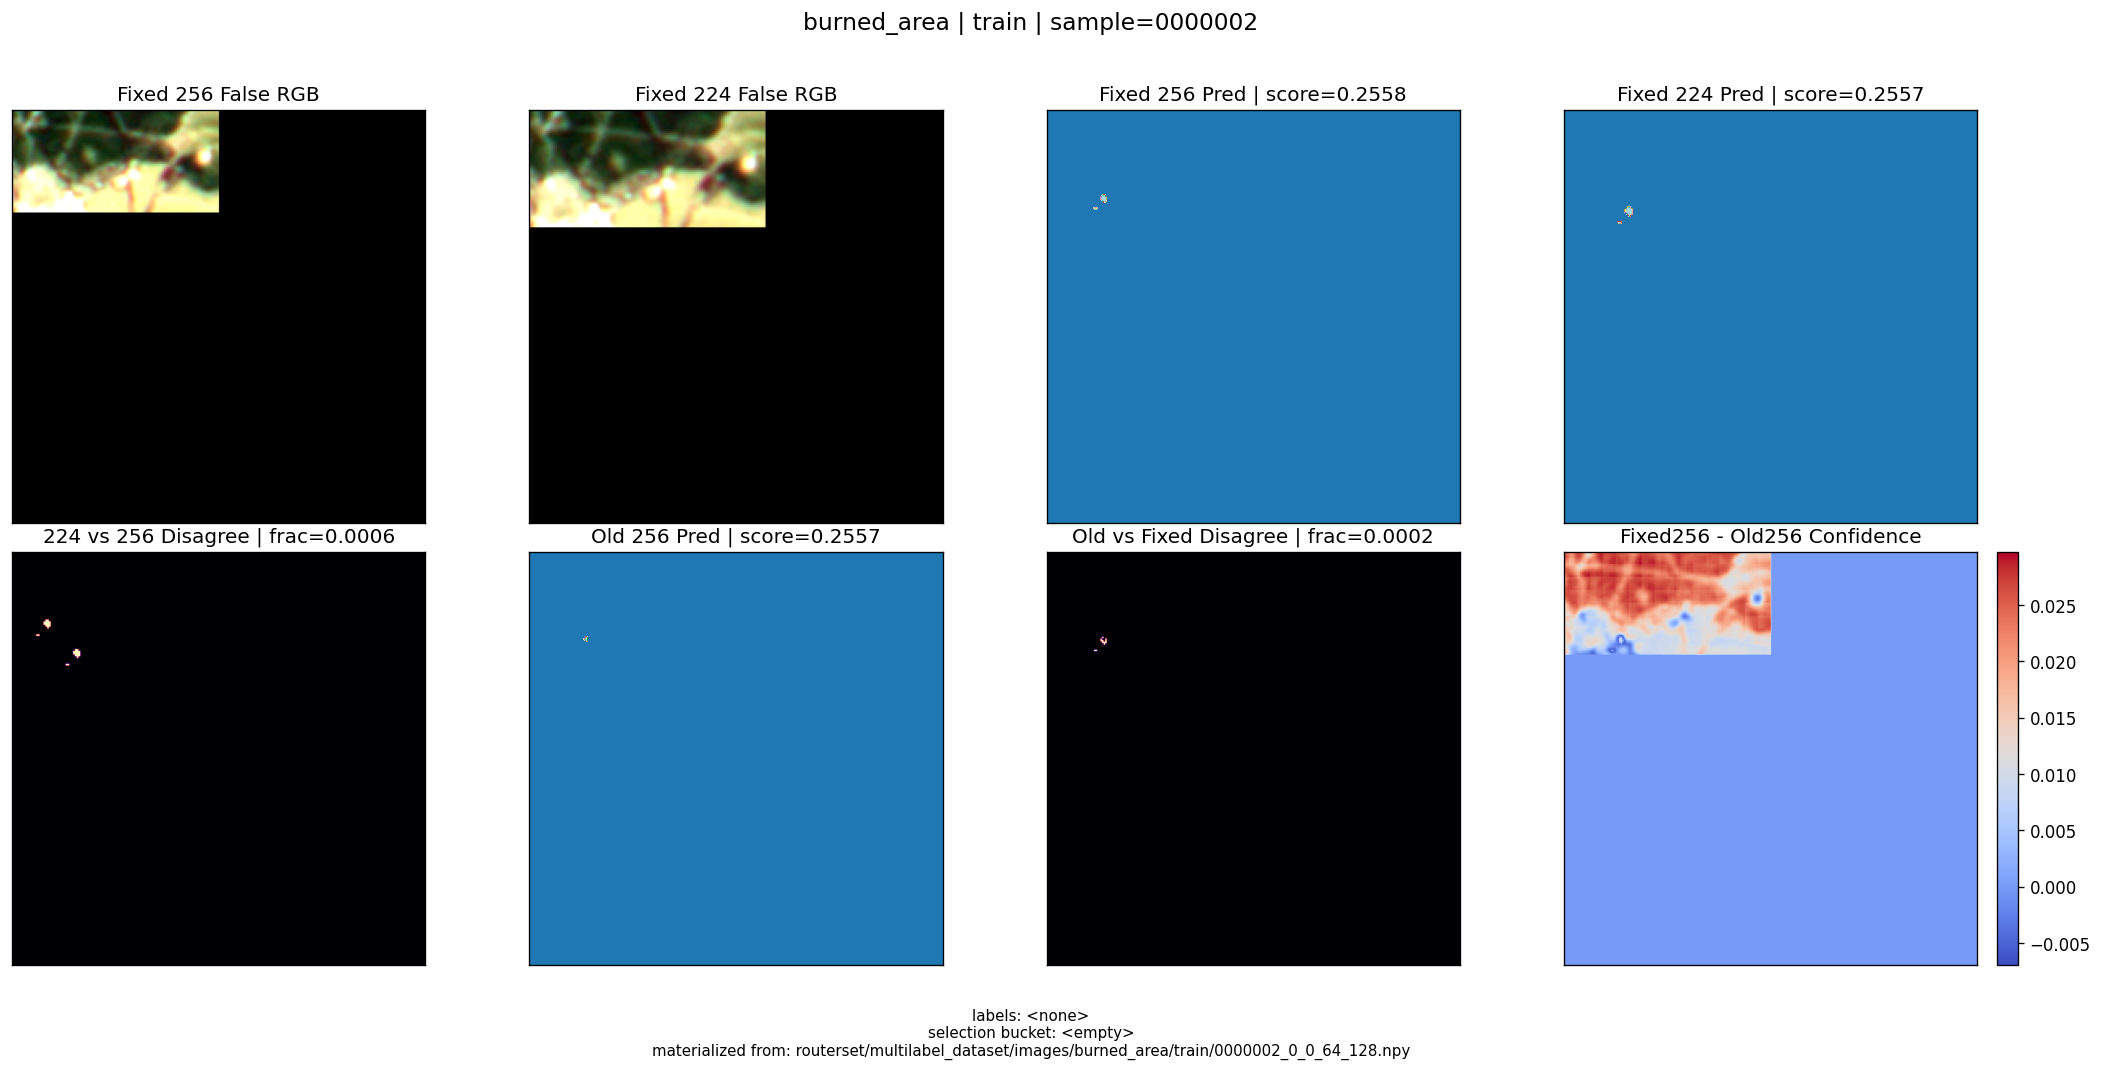

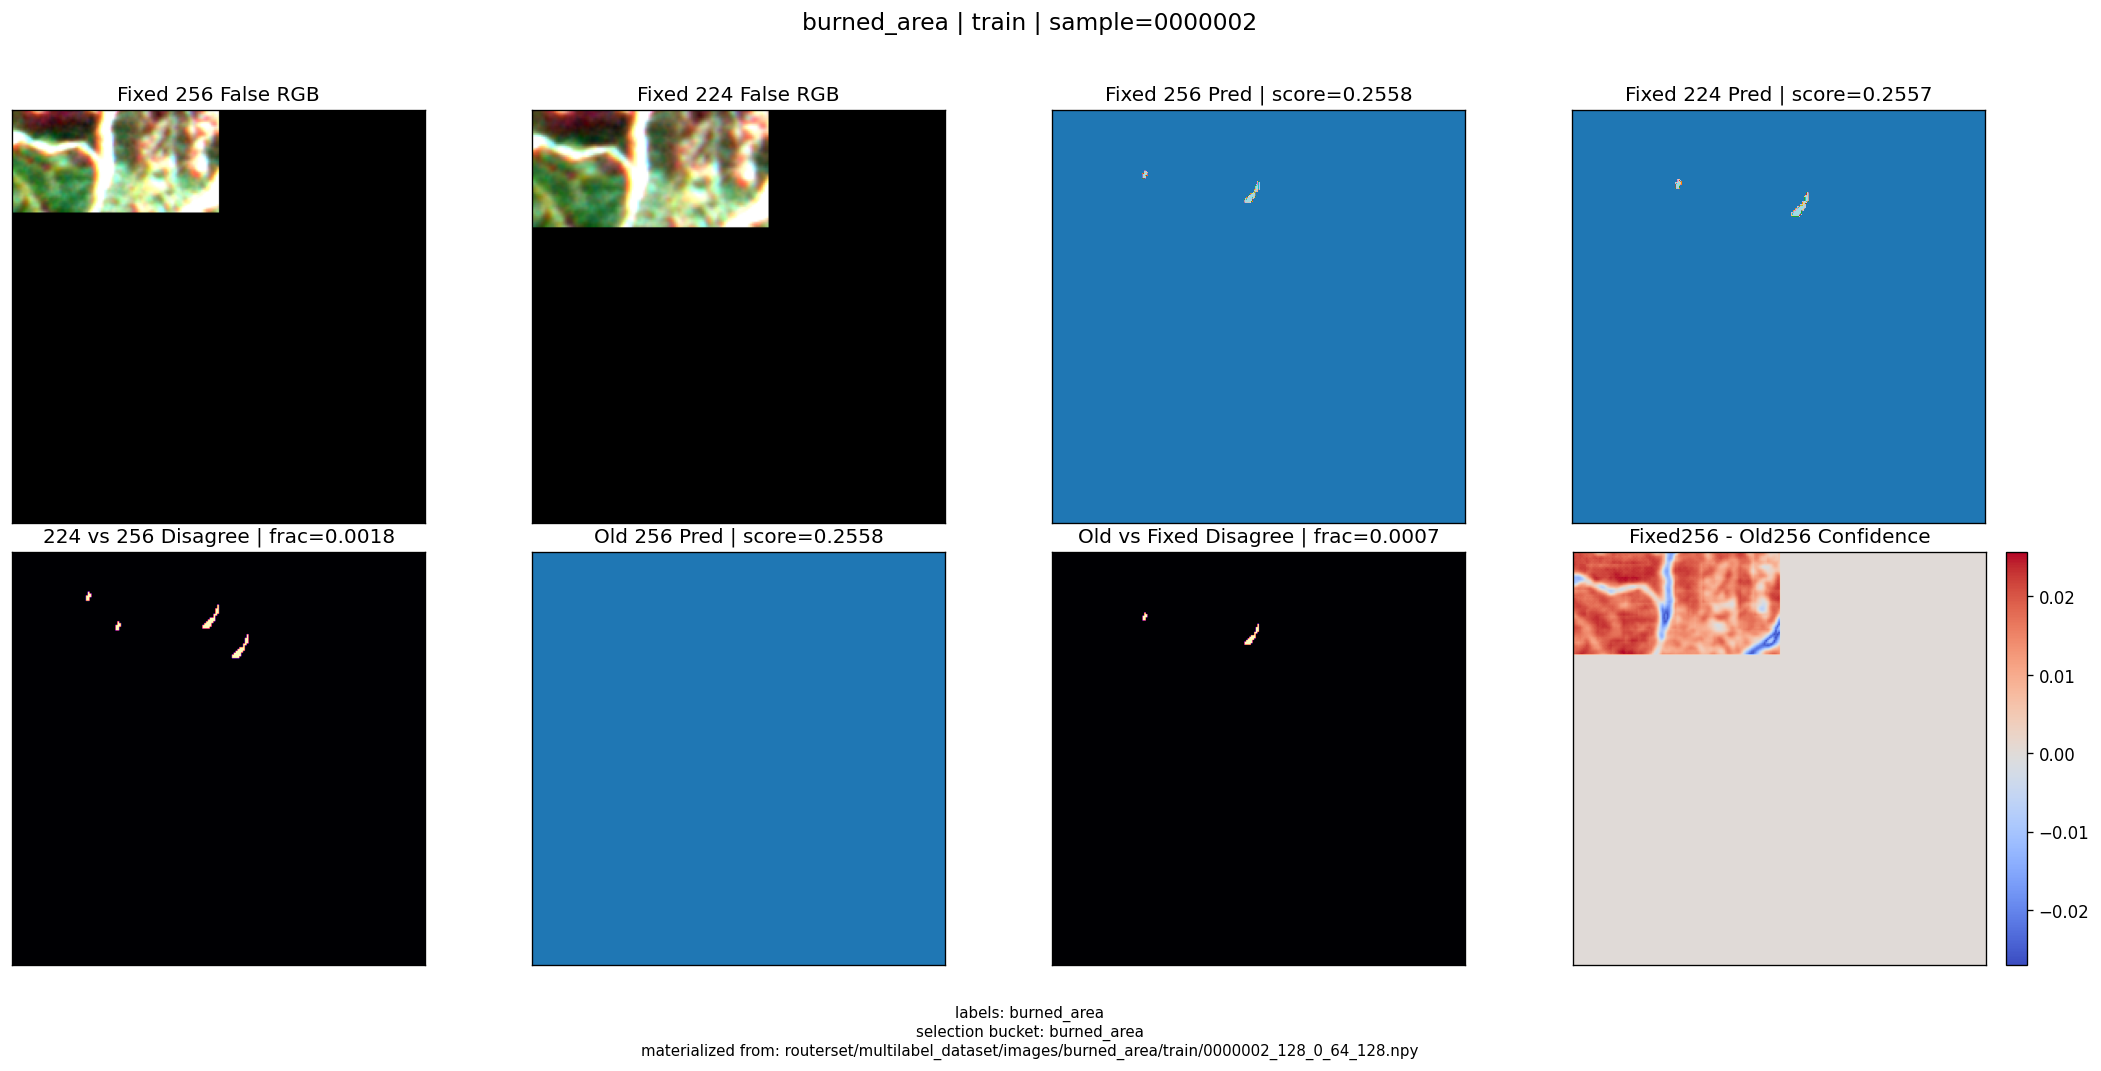

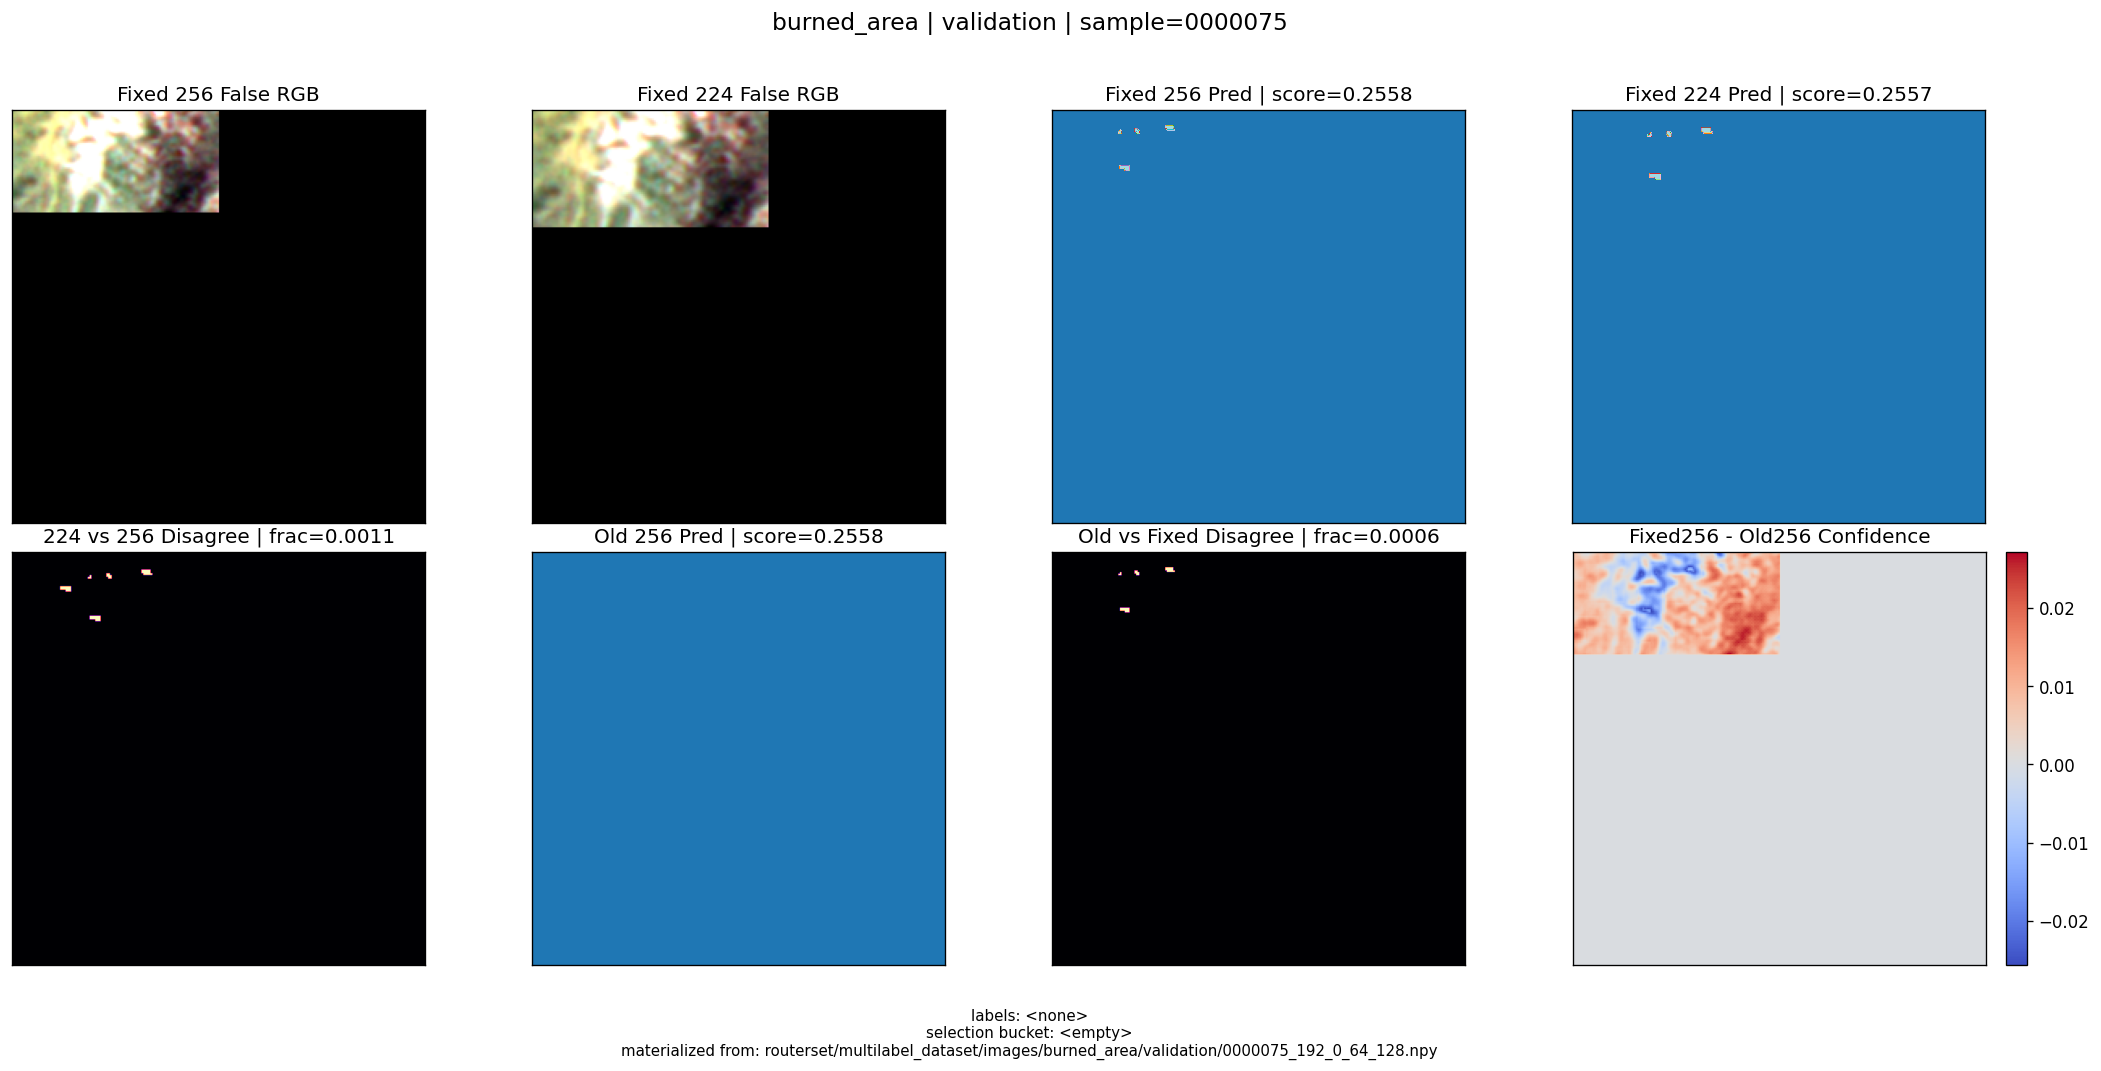

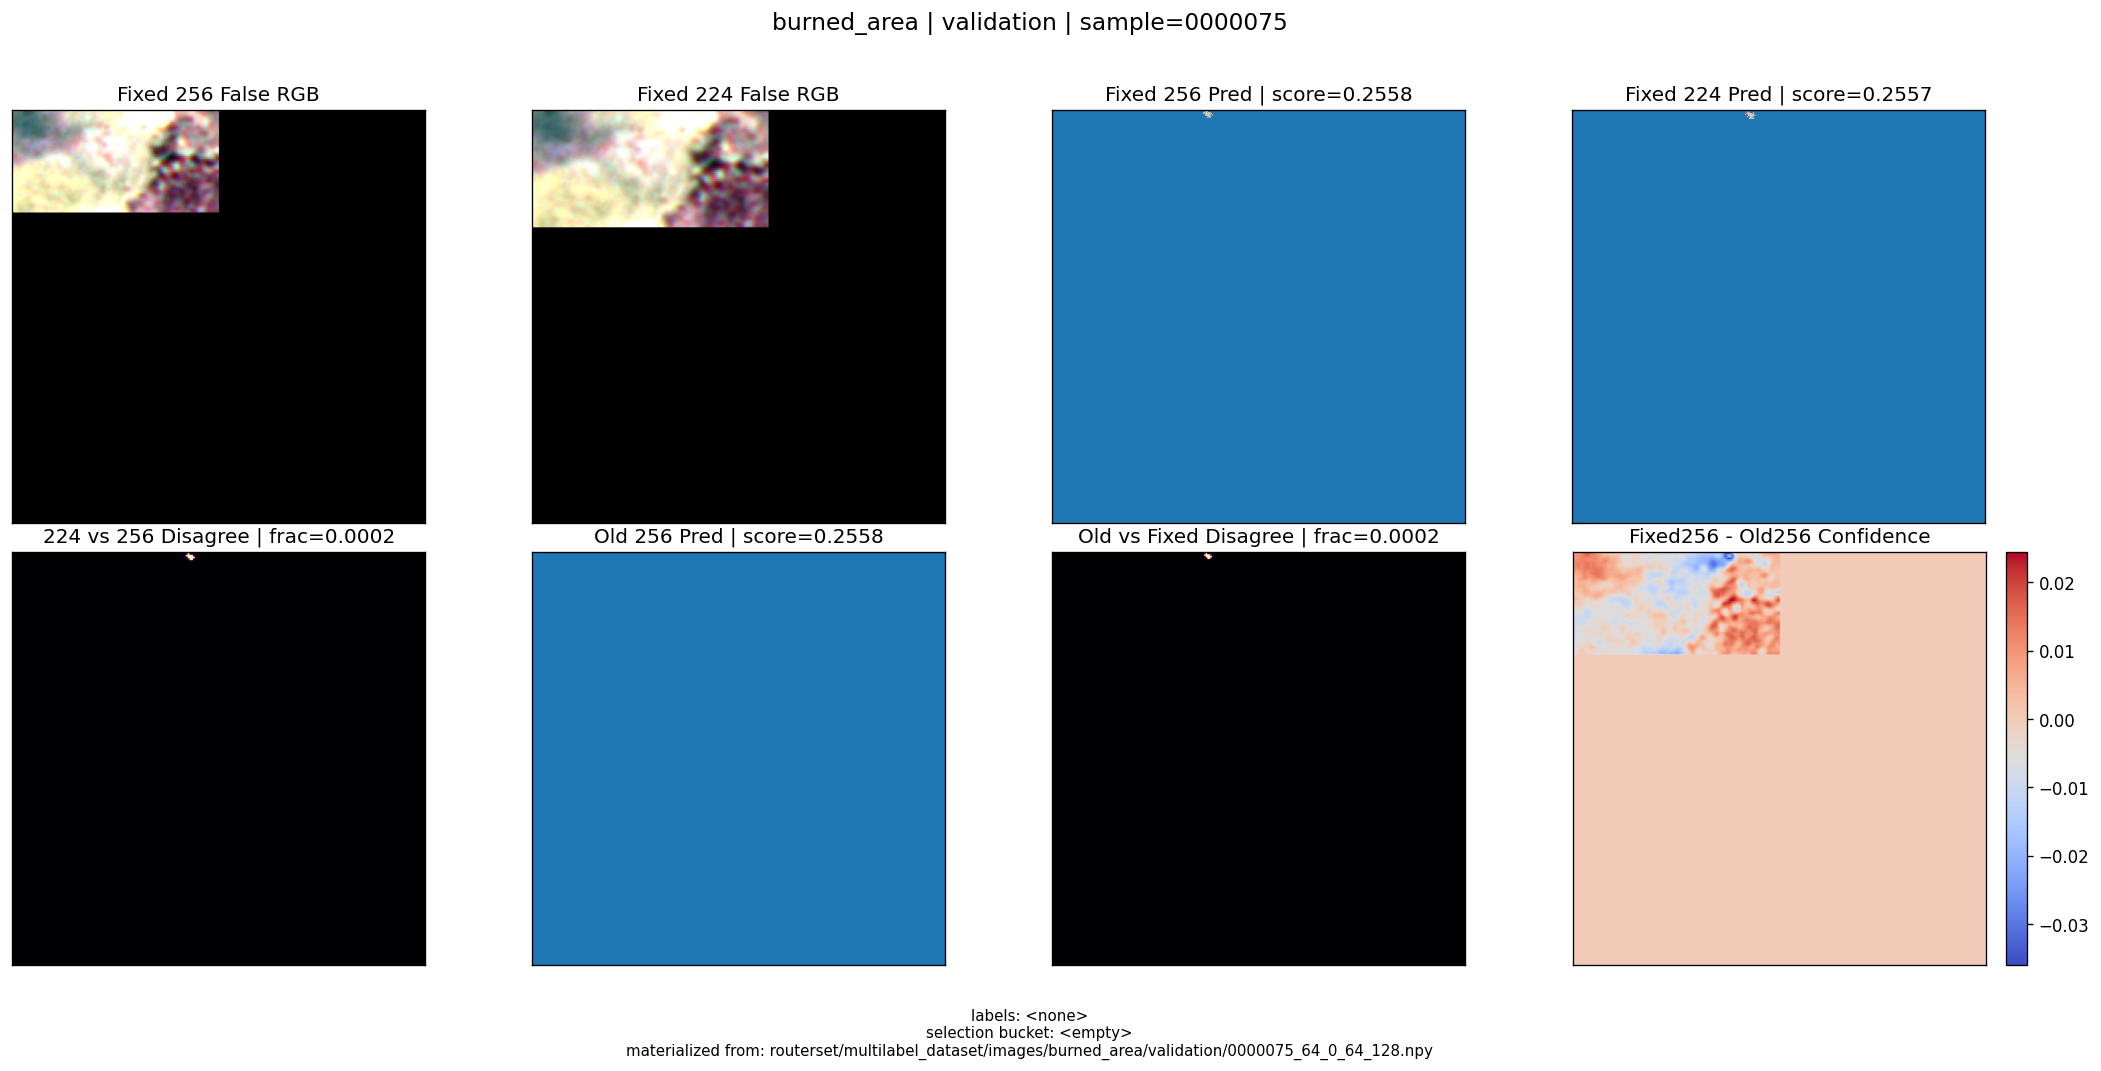

In [5]:
FALSE_RGB_CHANNELS = (4, 2, 1)  # B08, B04, B03


def render_burned_area_sample(row: dict, model: torch.nn.Module) -> None:
    fixed_256, _ = build_fixed_patch(row, target_size=TARGET_256)
    fixed_224, _ = build_fixed_patch(row, target_size=TARGET_224)
    old_256 = build_old_patch(row, target_size=TARGET_256)

    fixed_256_out = infer_patch(model, fixed_256)
    fixed_224_out = infer_patch(model, fixed_224)
    old_256_out = infer_patch(model, old_256)

    size_disagreement = (
        center_crop_array(fixed_256_out['pred'], TARGET_224) != fixed_224_out['pred']
    ).astype(np.float32)
    old_disagreement = (fixed_256_out['pred'] != old_256_out['pred']).astype(np.float32)
    old_conf_delta = fixed_256_out['conf'] - old_256_out['conf']

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(
        f"burned_area | {row.get('moe_split', row['source_split'])} | sample={row['source_sample_id']}",
        fontsize=14,
    )

    axes[0, 0].imshow(normalize_display(fixed_256, FALSE_RGB_CHANNELS))
    axes[0, 0].set_title('Fixed 256 False RGB')
    axes[0, 1].imshow(normalize_display(fixed_224, FALSE_RGB_CHANNELS))
    axes[0, 1].set_title('Fixed 224 False RGB')
    axes[0, 2].imshow(fixed_256_out['pred'], cmap='tab20')
    axes[0, 2].set_title(f"Fixed 256 Pred | score={fixed_256_out['score']:.4f}")
    axes[0, 3].imshow(fixed_224_out['pred'], cmap='tab20')
    axes[0, 3].set_title(f"Fixed 224 Pred | score={fixed_224_out['score']:.4f}")

    axes[1, 0].imshow(size_disagreement, cmap='magma', vmin=0.0, vmax=1.0)
    axes[1, 0].set_title(f"224 vs 256 Disagree | frac={size_disagreement.mean():.4f}")
    axes[1, 1].imshow(old_256_out['pred'], cmap='tab20')
    axes[1, 1].set_title(f"Old 256 Pred | score={old_256_out['score']:.4f}")
    axes[1, 2].imshow(old_disagreement, cmap='magma', vmin=0.0, vmax=1.0)
    axes[1, 2].set_title(f"Old vs Fixed Disagree | frac={old_disagreement.mean():.4f}")
    im = axes[1, 3].imshow(old_conf_delta, cmap='coolwarm')
    axes[1, 3].set_title('Fixed256 - Old256 Confidence')
    fig.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    text = '\n'.join(
        [
            f"labels: {', '.join(row.get('label_names') or []) or '<none>'}",
            f"selection bucket: {row.get('selection_bucket')}",
            f"materialized from: {row.get('materialized_from')}",
        ]
    )
    fig.text(0.5, 0.01, text, ha='center', va='bottom', fontsize=9)
    plt.tight_layout(rect=(0, 0.08, 1, 0.96))
    plt.show()


display(Markdown('## Burned Area Visual Focus'))
for row in probe_rows_by_expert['burned_area']:
    render_burned_area_sample(row, models['burned_area'])


In [6]:
display(Markdown('## Recommendation'))

burned = probe_report['per_expert']['burned_area']
text = f'''
- `burned_area` fixed-vs-old mean logit MAE: `{burned["old_vs_fixed_mean_logit_mae"]:.4f}`
- `burned_area` 224-vs-256 mean logit MAE: `{burned["size_224_vs_256_mean_logit_mae"]:.4f}`
- `burned_area` fixed256-vs-materialized mean MAE: `{burned["mean_materialized_match_mae"]:.6f}`

Interpretation:

- if `old_vs_fixed` is larger than `224 vs 256`, the preprocessing fix mattered more than the remaining size mismatch
- if `224 vs 256` stays material, the next real contract issue is spatial size, not normalization
'''
display(Markdown(text))


## Recommendation


- `burned_area` fixed-vs-old mean logit MAE: `0.0040`
- `burned_area` 224-vs-256 mean logit MAE: `0.0080`
- `burned_area` fixed256-vs-materialized mean MAE: `0.000000`

Interpretation:

- if `old_vs_fixed` is larger than `224 vs 256`, the preprocessing fix mattered more than the remaining size mismatch
- if `224 vs 256` stays material, the next real contract issue is spatial size, not normalization
